#Task 1 — Data Loading & Exploration

In [ ]:
# import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# load the dataset

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
# display first 10 rows

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [ ]:
# check dataset size (or no. of rows & columns)

print("number of rows :", df.shape[0])
print("number of columns :", df.shape[1])

number of rows : 1470
number of columns : 35


In [ ]:
# identify target column

print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [ ]:
# calculate attrition percentage

attrition_percentage = (
    df["Attrition"]
    .value_counts(normalize=True)
    * 100
)

print(attrition_percentage)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [ ]:
# identify number of numerical and categorical columns

numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(include="object").columns

print("number of numerical columns :", len(numerical_columns))
print("number of categorical columns :", len(categorical_columns))

number of numerical columns : 26
number of categorical columns : 9


observation : the dataset is imbalanced because most employees stayed in the company.

#Task 2 — Data Cleaning & Preprocessing

In [ ]:
# create a copy of original dataset (need to take a copy, otherwise will face problem in "EDA" if modify original dataset)
data = df.copy()

In [ ]:
# check and handle missing values

print(data.isnull().sum())

total_missing = data.isnull().sum().sum()
print("\ntotal missing values :", total_missing)
if total_missing == 0:
    print("\nno missing values found. no handling is required.")
else:
    data.fillna(data.mode().iloc[0], inplace=True)
    print("\nmissing values handled successfully.")

Age                                  0
Attrition                            0
DailyRate                            0
DistanceFromHome                     0
Education                            0
EnvironmentSatisfaction              0
HourlyRate                           0
JobInvolvement                       0
JobLevel                             0
JobSatisfaction                      0
MonthlyIncome                        0
MonthlyRate                          0
NumCompaniesWorked                   0
PercentSalaryHike                    0
PerformanceRating                    0
RelationshipSatisfaction             0
StockOptionLevel                     0
TotalWorkingYears                    0
TrainingTimesLastYear                0
WorkLifeBalance                      0
YearsAtCompany                       0
YearsInCurrentRole                   0
YearsSinceLastPromotion              0
YearsWithCurrManager                 0
BusinessTravel_Travel_Frequently     0
BusinessTravel_Travel_Rar

In [ ]:
# drop unnecessary columns (that add no value to prediction)

drop_cols = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

data.drop(columns=drop_cols, inplace=True)

print(data.shape)

(1470, 31)


In [ ]:
# convert target column Attirition from Yes/No into 1 and 0

data["Attrition"] = data["Attrition"].map({
    "No": 0,
    "Yes": 1
})

data["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [ ]:
#Encoding all remaining categorical columns using one-hot encoding
# step-1 :- identify categorical columns
categorical_columns = data.select_dtypes(include="object").columns
#step-2 :- # apply one hot encoding
data = pd.get_dummies(
    data,
    columns=categorical_columns,
    drop_first=True
)

In [ ]:
# Scale numeric features using StandardScaler
# step-1 :- separate features and target
X = data.drop("Attrition", axis=1)
y = data["Attrition"]
# step-2 :- scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# step-3 :- convert scaled data into dataframe

X = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


#Task 3 — Exploratory Data Analysis — EDA

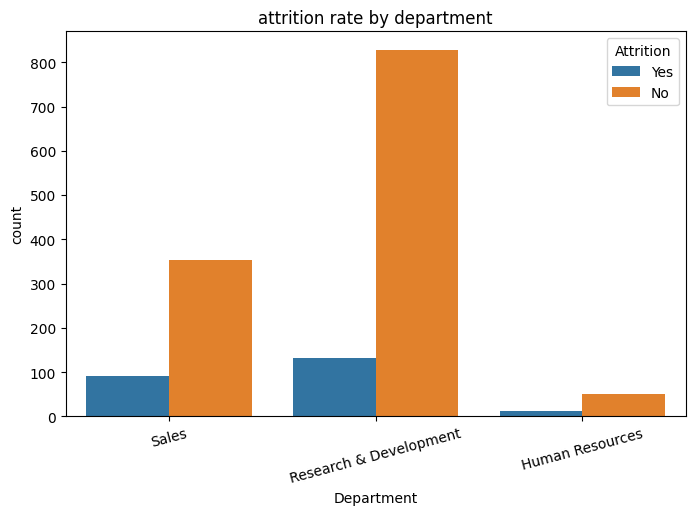

In [ ]:
# attrition rate by department

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("attrition rate by department")
plt.xticks(rotation=15)

plt.show()

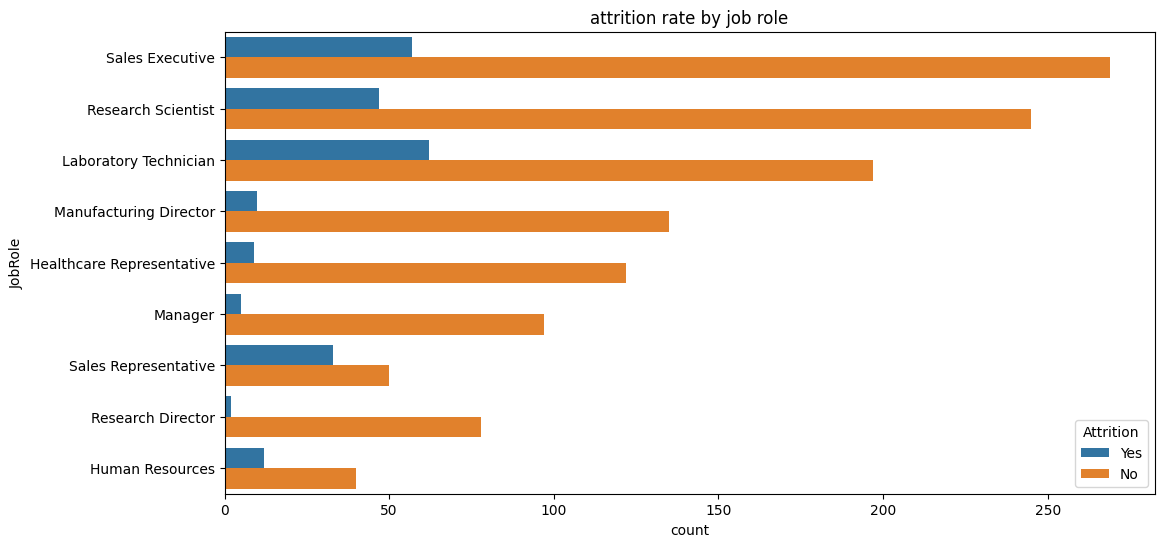

In [ ]:
# attrition rate by job role

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition"
)

plt.title("attrition rate by job role")

plt.show()

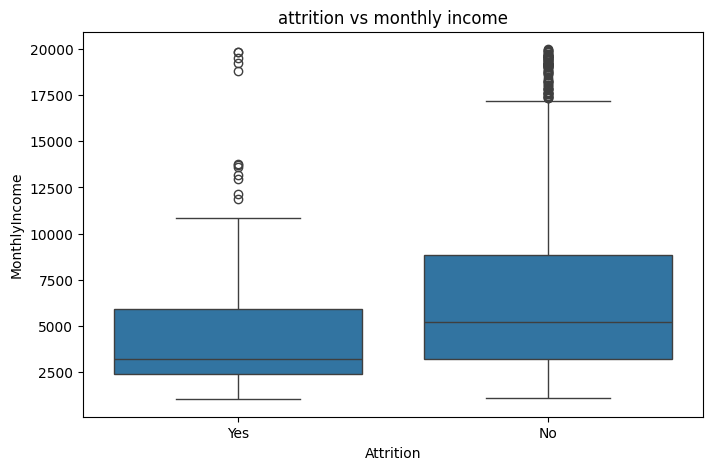

In [ ]:
# attrition vs monthly income

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("attrition vs monthly income")

plt.show()

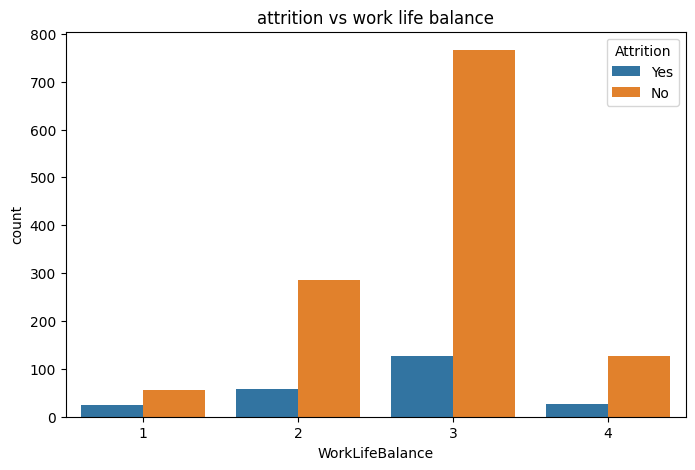

In [ ]:
# attrition vs work life balance

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("attrition vs work life balance")

plt.show()

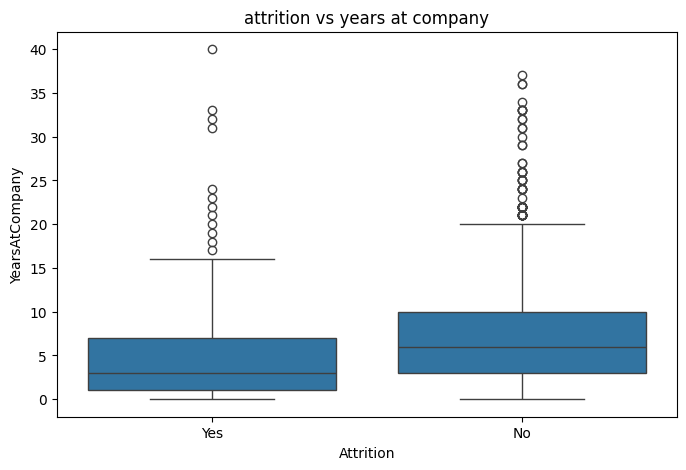

In [ ]:
# attrition vs years at company

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("attrition vs years at company")

plt.show()

In [ ]:
# attrition percentage by department

department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

print(department_attrition.round(2))
# attrition percentage by job role

jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

print(jobrole_attrition.sort_values(by="Yes", ascending=False).round(2))
# average monthly income

income = df.groupby("Attrition")["MonthlyIncome"].mean()

print(income.round(2))
# average years at company

years = df.groupby("Attrition")["YearsAtCompany"].mean()

print(years.round(2))
# average work life balance

worklife = df.groupby("Attrition")["WorkLifeBalance"].mean()

print(worklife.round(2))

Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63
Attrition                     No    Yes
JobRole                                
Sales Representative       60.24  39.76
Laboratory Technician      76.06  23.94
Human Resources            76.92  23.08
Sales Executive            82.52  17.48
Research Scientist         83.90  16.10
Manufacturing Director     93.10   6.90
Healthcare Representative  93.13   6.87
Manager                    95.10   4.90
Research Director          97.50   2.50
Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64
Attrition
No     7.37
Yes    5.13
Name: YearsAtCompany, dtype: float64
Attrition
No     2.78
Yes    2.66
Name: WorkLifeBalance, dtype: float64


Business Insights
1. The Sales department has the highest attrition rate at 20.63%, followed by Human Resources at 19.05%, while Research & Development has the lowest attrition rate at 13.84%.
2. Among all job roles, Sales Representatives have the highest attrition rate (39.76%), followed by Laboratory Technicians (23.94%) and Human Resources (23.08%). These roles require the highest retention focus.
3. Employees who left the company had a much lower average monthly income (4,787.09) compared to employees who stayed (6,832.74), indicating that lower salary is associated with higher employee attrition.
4. Employees who left the company had an average tenure of 5.13 years, whereas employees who stayed had an average tenure of 7.37 years. This suggests that employees are more likely to leave during the early years of their employment.
5. Employees who left the company had a slightly lower average Work-Life Balance score (2.66) than employees who stayed (2.78), indicating that poor work-life balance may also contribute to employee attrition.

#Task 4 — Model Building & Comparison

In [ ]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("training samples :", X_train.shape)
print("testing samples :", X_test.shape)

training samples : (1176, 44)
testing samples : (294, 44)


In [ ]:
# train logistic regression model

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("logistic regression model trained successfully")

logistic regression model trained successfully


In [ ]:
# train random forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("random forest model trained successfully")

random forest model trained successfully


In [ ]:
# train gradient boosting model

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("gradient boosting model trained successfully")

gradient boosting model trained successfully


In [ ]:
# create comparison table

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.748299
1,Random Forest,0.833333
2,Gradient Boosting,0.850340


#Task 5 — Model Evaluation

In [ ]:
# calculate evaluation metrics
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1])
    ]
})

comparison

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.375000,0.063830,0.109091,0.751917
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


In [ ]:
# identify best model

best_model = comparison.loc[
    comparison["F1 Score"].idxmax(),
    "Model"
]

print("best model :", best_model)
print("this is decided on the basis of F1 score comparision")

best model : Logistic Regression
this is decided on the basis of F1 score comparision


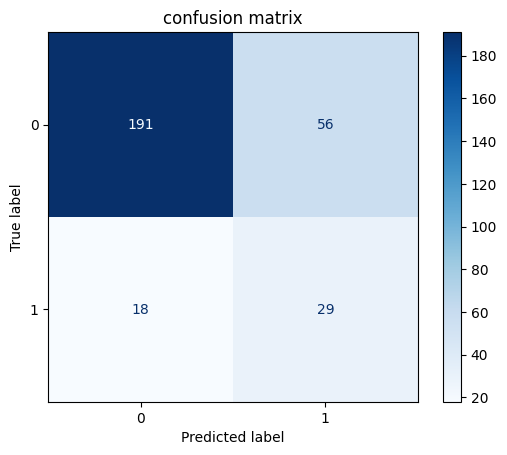

In [ ]:
# plot confusion matrix for best model

if best_model == "Logistic Regression":
    model = lr_model

elif best_model == "Random Forest":
    model = rf_model

else:
    model = gb_model

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("confusion matrix")
plt.show()

In [ ]:
# extract feature importance from best model

if best_model == "Random Forest":
    importance = rf_model.feature_importances_

elif best_model == "Gradient Boosting":
    importance = gb_model.feature_importances_

else:
    importance = abs(lr_model.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


In [ ]:
# rank top 10 features

top10_features = feature_importance.head(10).reset_index(drop=True)
top10_features.index = top10_features.index + 1
top10_features.index.name = "Rank"
top10_features

,Feature,Importance
Rank,,
1,JobRole_Laboratory Technician,0.797874
2,OverTime_Yes,0.766412
3,BusinessTravel_Travel_Frequently,0.719335
4,JobLevel,0.659189
5,TotalWorkingYears,0.656931
6,JobRole_Sales Representative,0.552515
7,BusinessTravel_Travel_Rarely,0.511649
8,EducationField_Life Sciences,0.506505
9,YearsSinceLastPromotion,0.500389


#Task 6 — Visualization


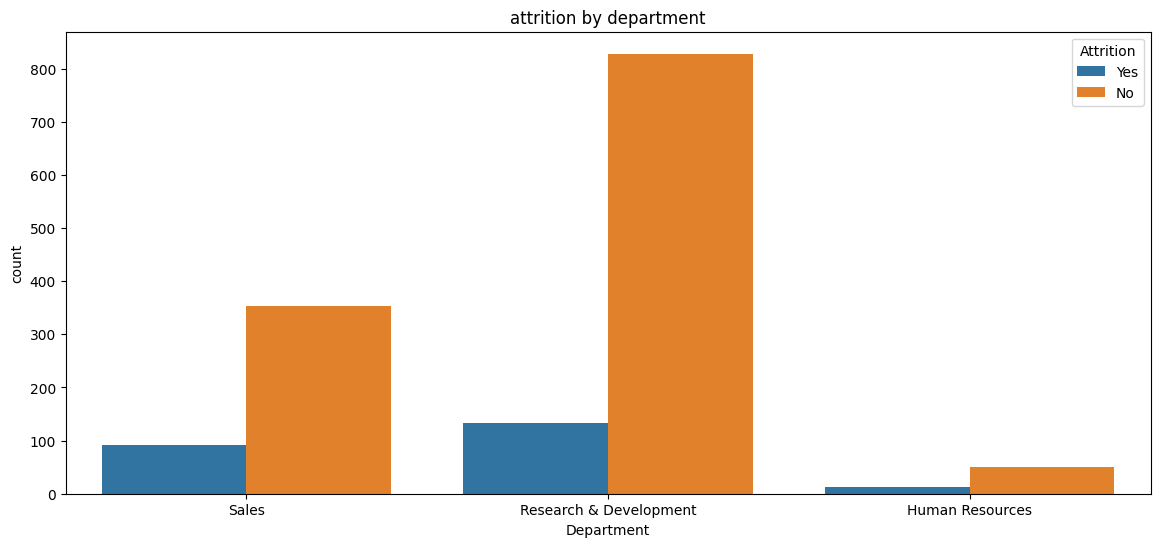

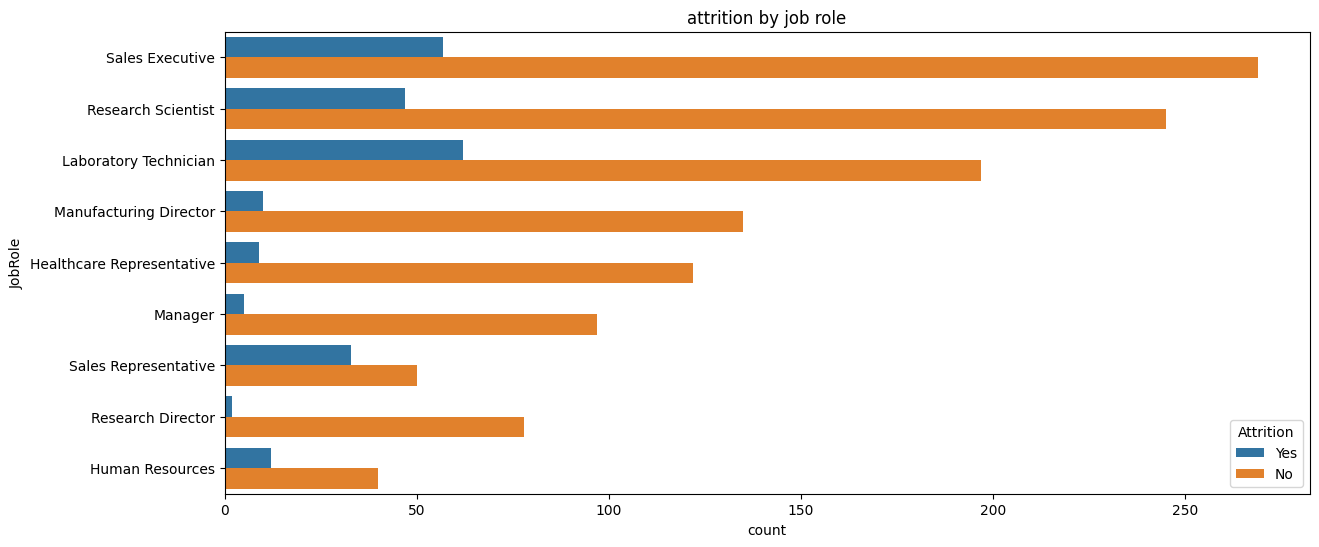

In [ ]:
# chart 1

plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("attrition by department")

plt.show()


plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition"
)

plt.title("attrition by job role")
plt.savefig("chart1_department_jobrole.png", dpi=300, bbox_inches="tight")
plt.show()


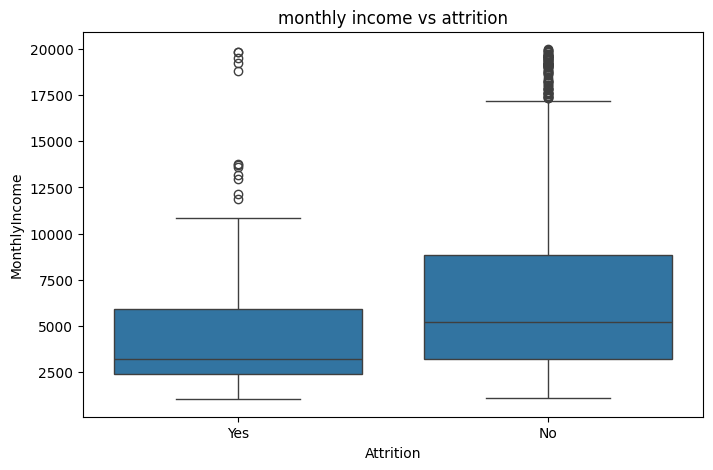

In [ ]:
# chart 2

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("monthly income vs attrition")
plt.savefig("chart2_monthly_income.png", dpi=300, bbox_inches="tight")
plt.show()

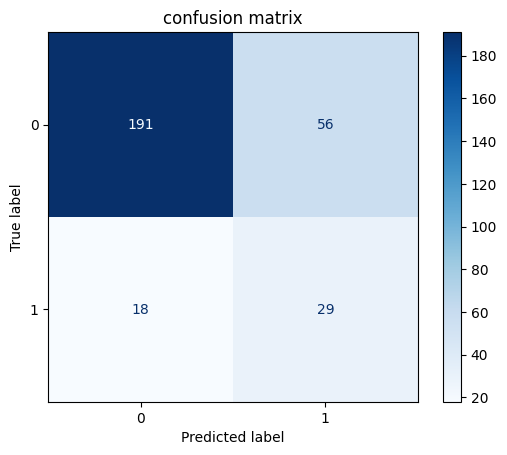

In [ ]:
# chart 3

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("confusion matrix")
plt.savefig("chart3_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

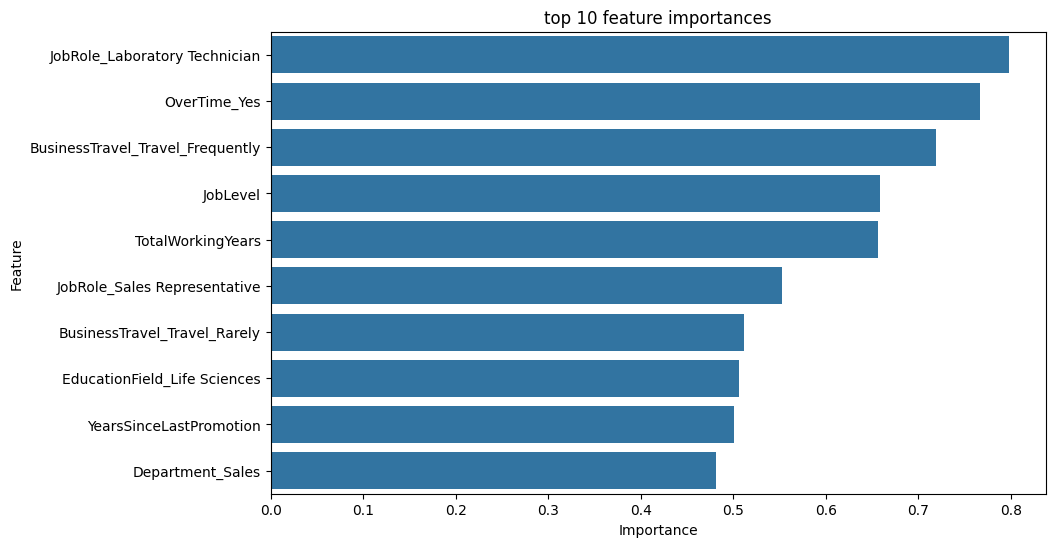

In [ ]:
# chart 4

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_features,
    x="Importance",
    y="Feature"
)

plt.title("top 10 feature importances")
plt.savefig("chart4_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x600 with 0 Axes>

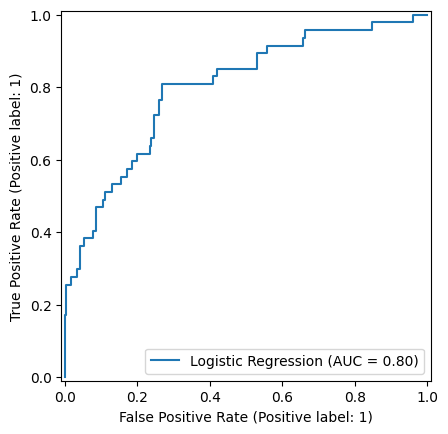

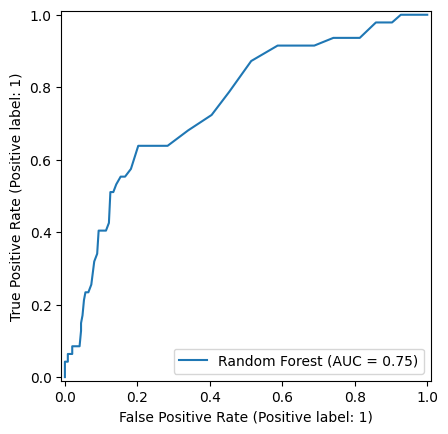

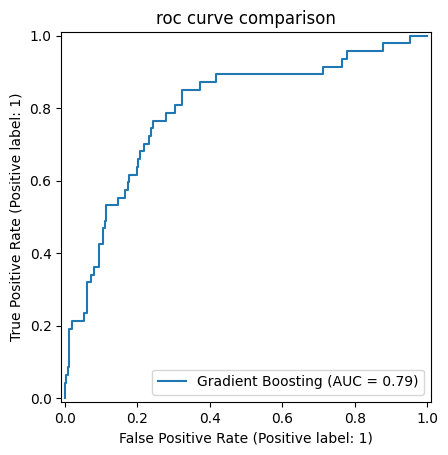

In [ ]:
# chart 5

lr_prob = lr_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
gb_prob = gb_model.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    gb_prob,
    name="Gradient Boosting"
)

plt.title("roc curve comparison")
plt.savefig("chart5_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

#Task 7 — HR Insights & Business Recommendations

Based on the analysis, the three strongest factors associated with employee attrition are monthly income, years at the company, and work-life balance. Employees with lower salaries, shorter tenure, and slightly poorer work-life balance were more likely to leave the organization. The Sales department showed the highest attrition rate (20.63%), while Sales Representatives had the highest attrition among all job roles (39.76%), so HR should prioritize retention efforts for these employees. Salary alone does not fully explain attrition, as factors such as employee tenure and work-life balance also play an important role. First, the company should introduce targeted retention programs, career development opportunities, and regular one-on-one discussions for employees in high-risk departments and job roles. Second, HR should improve work-life balance through flexible work policies and employee wellness initiatives, especially for employees in their early years with the company. Finally, this model should be used only as a decision-support tool because it predicts attrition based on historical data and cannot capture personal reasons, future organizational changes, or individual employee circumstances.